In [1]:
print("om")

om


In [2]:
import sys
import pickle
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from src.quantum.candidate_evaluation import CandidateEvaluator
from src.second_encoding import SecondEncoder
from src.quantum.state_construction import StateConstructionBuilder
from src.quantum.swap_test import SwapTestBuilder
# from qiskit_ibm_runtime import QiskitRuntimeService


In [3]:
with open(
    PROJECT_ROOT / "outputs" / "project_data.pkl",
    "rb",
) as f:
    project_data = pickle.load(f)

In [4]:
with open(
    PROJECT_ROOT /
    "outputs" /
    "candidate_evaluation" /
    "matched_candidates.pkl",
    "rb",
) as f:
    matched_candidates = pickle.load(f)

print(len(matched_candidates))

2


In [5]:
print(matched_candidates)

[SearchResult(pattern=SearchPattern(encoded_window=((1, 1), (0, 0)), occurrences=[(2, 3)], interaction_values=[((np.float64(1.77), np.float64(1.29)), (np.float64(0.28), np.float64(-1.13)))]), probability=0.56640625, counts=580, shift_id=3), SearchResult(pattern=SearchPattern(encoded_window=((1, 1), (0, 0)), occurrences=[(5, 6)], interaction_values=[((np.float64(2.83), np.float64(0.79)), (np.float64(1.23), np.float64(-1.23)))]), probability=0.3505859375, counts=359, shift_id=4)]


In [6]:
ligand_interactions = tuple(
    (
        row["Hydrophobic"],
        row["Hydrogen_Bond"],
    )
    for _, row in project_data.ligand.iterrows()
)

In [7]:
encoder = SecondEncoder(
    project_data.interaction_ranges
)

candidate = matched_candidates[1]

encoding_result = encoder.build(
    candidate,
    ligand_interactions,
)

In [8]:
encoding_result

SecondEncodingResult(occurrence=(5, 6), probability=0.3505859375, ligand_vector=array([0.02219539, 0.03141212, 0.40744399, 0.57663683, 0.61764433,
       0.34426077, 0.        , 0.        ]), protein_vector=array([0.        , 0.        , 0.21891039, 0.67236764, 0.5803228 ,
       0.02773602, 0.40259894, 0.01924186]))

In [9]:
builder = StateConstructionBuilder()

state_result = builder.build(encoding_result)

In [10]:
swap = SwapTestBuilder()

result = swap.run(
    state_result,
    hardware="simulator",
    shots=4096,
)

In [11]:
print(result)

SwapTestResult(occurrence=(5, 6), probability=0.3505859375, counts={'0': 2251, '1': 1845}, p0=0.549560546875, distance=0.6296700524878088, Z=np.float64(1.9999999999999996))


In [12]:
result.counts

{'0': 2251, '1': 1845}

In [13]:
print(result.p0)

0.549560546875


In [14]:
print(result.distance)

0.6296700524878088


In [15]:
import numpy as np

classical_distance = np.linalg.norm(encoding_result.ligand_vector - encoding_result.protein_vector
)

print("Classical :", classical_distance)
print("Quantum   :", result.distance)

Classical : 0.5569790289389036
Quantum   : 0.6296700524878088


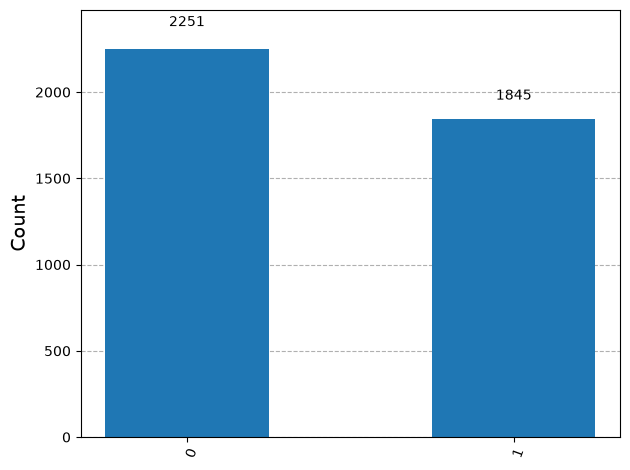

In [16]:
from qiskit.visualization import plot_histogram

plot_histogram(result.counts)

In [17]:
from qiskit_ibm_runtime import QiskitRuntimeService
def get_ibm_backend():
    QiskitRuntimeService.save_account(channel="ibm_quantum_platform",
                              instance="crn:v1:bluemix:public:quantum-computing:us-east:a/752e715c5ece4d4eb056d138831cfae9:ab616613-4c94-406b-8698-ff7922ea54f2::",
                              token="fBiJzlm4dpNzt08zilBN16hDWHE8w7_jPVvbuqKLjiDB",overwrite=True)
    #Get the runtimeService to do the operations in cloud.
    service = QiskitRuntimeService()
            
    # Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
    # backend = service.backend("ibm_kingston")
    print(f"backend using:{backend.name}")
    return backend

In [18]:
result = swap.run(
    state_result,
    backend=get_ibm_backend(),
    hardware="hardware",
    shots=4096,
)

backend using:ibm_kingston


In [19]:
print(result)

SwapTestResult(occurrence=(5, 6), probability=0.3505859375, counts={'1': 1795, '0': 2301}, p0=0.561767578125, distance=0.7029513674501244, Z=np.float64(1.9999999999999996))


In [20]:
result.counts

{'1': 1795, '0': 2301}

In [21]:
print(result.p0)

0.561767578125


In [22]:
print(result.distance)

0.7029513674501244


In [23]:
import numpy as np

classical_distance = np.linalg.norm(encoding_result.ligand_vector - encoding_result.protein_vector
)

print("Classical :", classical_distance)
print("Quantum   :", result.distance)

Classical : 0.5569790289389036
Quantum   : 0.7029513674501244


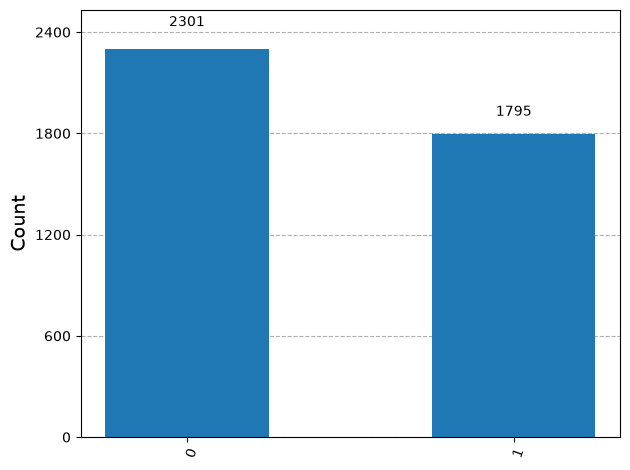

In [24]:
from qiskit.visualization import plot_histogram

plot_histogram(result.counts)